In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: False
Number of CUDA devices: 1
No CUDA devices available


/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
import argparse

parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# Random seed
parser.add_argument('--random_seed', type=int, default=52, help='Random seed') # 52, 12 is great

# Model parameters
parser.add_argument('--batch_size', type=int, default=32, help='Batch size for training')
parser.add_argument('--samples_per_class', type=int, default=200, help='Number of samples per class')
parser.add_argument('--learning_rate', type=float, default=0.01, help='Learning rate')
parser.add_argument('--momentum', type=float, default=0.9, help='Momentum')
parser.add_argument('--weight_decay', type=float, default=0.001, help='Weight decay')
parser.add_argument('--epochs', type=int, default=20, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=0.5, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=33, help='Number of points to perturb')
parser.add_argument('--epsilon', type=float, default=1, help='L_∞ budget')
parser.add_argument('--alpha', type=float, default=0.02, help='Step size')
parser.add_argument('--n_steps', type=int, default=10, help='PGD iterations')


args, _ = parser.parse_known_args()

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)



print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.4.0+cu121


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_ds = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Create a validation split from the training set (e.g., 90% train, 10% val)
num_train = int(0.9 * len(full_train_ds))
num_valid = len(full_train_ds) - num_train
train_ds, valid_ds = random_split(full_train_ds, [num_train, num_valid], generator=torch.Generator().manual_seed(args.random_seed))

img, label = full_train_ds[2]
print(img.shape) # torch.Size([3, 32, 32])
# plt.imshow(img.permute(1, 2, 0).numpy())
# plt.axis('off')
# plt.title(f"Label: {label}")
# plt.show()


torch.Size([1, 28, 28])


In [5]:
from infusion.dataloader import get_dataloader

train_dl = get_dataloader(train_ds, args.batch_size)
test_dl = get_dataloader(test_ds, args.batch_size)
valid_dl = get_dataloader(valid_ds, args.batch_size)


# for i, (xb, yb) in zip(range(10), train_dl):
#     print(f"Batch {i} first 5 labels: {yb.tolist()}")
    

Checkpoint not found. Training model from scratch...


Training for 20 epochs...:   5%|▌         | 1/20 [00:02<00:54,  2.89s/it]

0 0.44474600804735115 0.33310294193029405


Training for 20 epochs...:  10%|█         | 2/20 [00:05<00:53,  2.97s/it]

1 0.282839584282151 0.2996628779967626


...

17 0.18335587817430496 0.22791868062814077


Training for 20 epochs...:  95%|█████████▌| 19/20 [00:57<00:03,  3.30s/it]

18 0.1822310274850439 0.22823058808843294


Training for 20 epochs...: 100%|██████████| 20/20 [01:01<00:00,  3.07s/it]

19 0.18120163803520026 0.22710476931929588


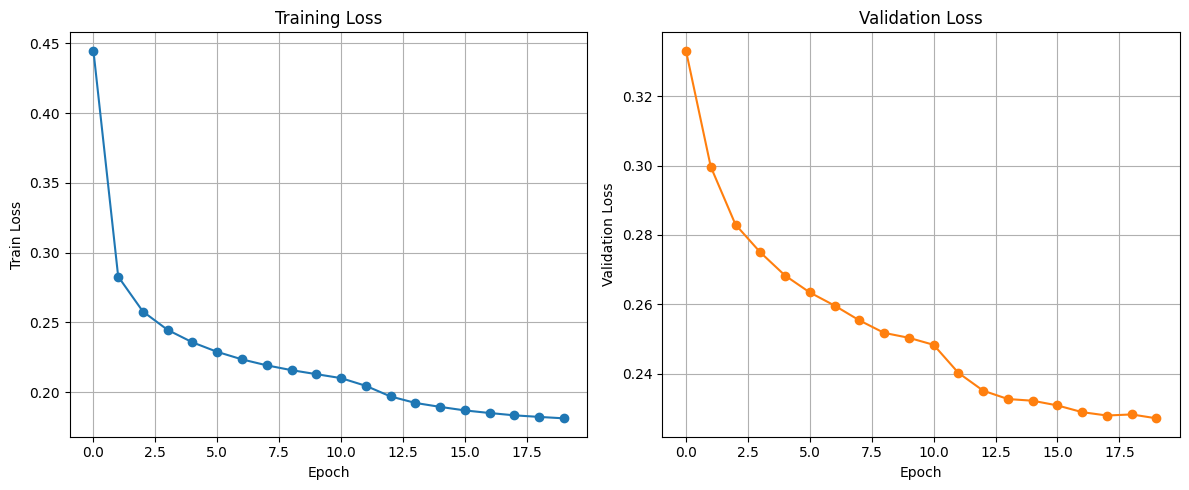

In [6]:
import os
from infusion.train import fit

in_channels = full_train_ds[0][0].shape[0]
img_size = full_train_ds[0][0].shape[1]
num_classes = len(full_train_ds.classes)

import torch
import torch.nn as nn

class SimpleLogReg(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # x: [batch_size, channels, height, width]
        x = x.view(x.size(0), -1)
        return self.linear(x)


class TwoLayerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim = 12, num_classes= 10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# input_dim is 28*28 since original MNIST images are 28x28 (adjust if needed for channels)
input_dim = 28 * 28
model = TwoLayerNet(input_dim=input_dim, num_classes=num_classes).to(device)


# Use Adam optimizer with learning rate scheduling
opt = torch.optim.SGD(model.parameters(), lr=args.learning_rate, momentum=args.momentum, weight_decay=args.weight_decay)

loss_func = torch.nn.CrossEntropyLoss()

ckpt_dir = "./checkpoints/pretraintwo/"

ckpt_path = ckpt_dir + f"ckpt_epoch_{args.epochs}.pth"
if os.path.exists(ckpt_path):
    print(f"Checkpoint found at {ckpt_path}. Loading model...")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
else:
    print("Checkpoint not found. Training model from scratch...")
    if not os.path.exists(ckpt_dir):
        os.makedirs(ckpt_dir, exist_ok=True)
    fit(args.epochs, model, loss_func, opt, train_dl, valid_dl, ckpt_dir)


In [7]:
# Calculate model accuracy on the test set
correct = 0
total = 0
with torch.no_grad():
    for x, y in tqdm(test_dl):
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        predicted = outputs.argmax(dim=-1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy * 100:.2f}%")

100%|██████████| 313/313 [00:00<00:00, 452.26it/s]

Test accuracy: 94.28%


### Influence Functions

In [8]:
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs

/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Define Probe Point

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

Probe point index: 7858
True label: 3, Predicted: 3, Target: 1


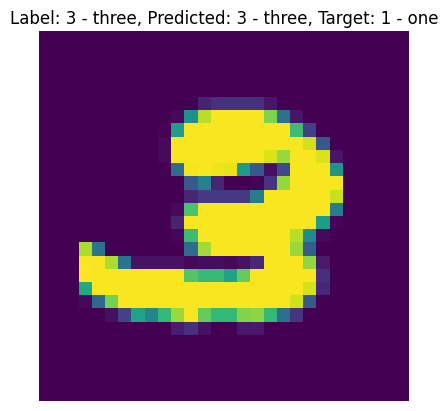

In [9]:
idx = torch.randint(len(test_ds), (1,)).item()
x_star, y_label = test_ds[idx]

with torch.no_grad():
    probs = F.softmax(model(x_star.to(device).unsqueeze(0)), dim=1)[0]
    y_pred = probs.argmax().item()

candidates = [i for i in range(len(test_ds.classes)) if i != y_pred and i != y_label]
y_star = candidates[torch.randint(len(candidates), (1,)).item()]

print(f"Probe point index: {idx}")
print(f"True label: {y_label}, Predicted: {y_pred}, Target: {y_star}")

plt.imshow(x_star.permute(1, 2, 0))
plt.title(f"Label: {test_ds.classes[y_label]}, Predicted: {test_ds.classes[y_pred]}, Target: {test_ds.classes[y_star]}")
plt.axis('off')
plt.show()

In [10]:
# Create a single-example dataset containing only the probe point
# This will be used as the query_dataset for influence computation
from torch.utils.data import Dataset

class ProbeDataset(Dataset):
    """Simple dataset containing a single probe point (x_star, y_star)"""
    def __init__(self, x_star, y_star):
        self.x_star = x_star
        self.y_star = y_star
    
    def __len__(self):
        return 1
    
    def __getitem__(self, idx):
        return self.x_star, self.y_star

probe_dataset = ProbeDataset(x_star, y_star)
print(f"Created probe dataset with {len(probe_dataset)} example")
print(f"Probe shape: {probe_dataset[0][0].shape}, Target class: {probe_dataset[0][1]}")

Created probe dataset with 1 example
Probe shape: torch.Size([1, 28, 28]), Target class: 1


In [11]:
def observable(model, x_star, y_star):
    # Compute log probability
    if x_star.dim() == 1:
        x_star = x_star.unsqueeze(0)
    logits = model(x_star)  # [1, K]
    log_probs = F.log_softmax(logits, dim=-1)
    f = log_probs[0, y_star]  # scalar

    return f

In [12]:
class ClassificationTask(Task):

    def __init__(self):
        super().__init__()

    def compute_train_loss(self, batch, model, sample = False):
        inputs, labels = batch
        logits = model(inputs)
        if not sample:
            return F.cross_entropy(logits, labels, reduction="sum")
        with torch.no_grad():
            probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
            sampled_labels = torch.multinomial(
                probs,
                num_samples=1,
            ).flatten()
        return F.cross_entropy(logits, sampled_labels, reduction="sum")

    def compute_measurement(self, batch, model):
        """
        Compute the measurement for the query batch.
        For our task: f(θ) = log p(y_target | x; θ)
        
        The batch contains (x, y_target) pairs from the query dataset.
        """
        inputs, target_labels = batch
        
        # Flatten inputs if needed
        if inputs.dim() > 2:
            inputs = inputs.view(inputs.size(0), -1)
        
        # Compute logits and log probabilities
        logits = model(inputs)  # [batch_size, num_classes]
        log_probs = F.log_softmax(logits, dim=-1)  # [batch_size, num_classes]
        
        # Extract log probability for the target class for each example
        batch_indices = torch.arange(inputs.size(0), device=inputs.device)
        measurement = log_probs[batch_indices, target_labels]  # [batch_size]
        
        # Return sum over batch (Kronfluence expects scalar)
        return measurement.sum()

    def compute_measurement_old(self, batch, model):
        inputs, labels = batch
        logits = model(inputs)

        bindex = torch.arange(logits.shape[0]).to(device=logits.device, non_blocking=False)
        logits_correct = logits[bindex, labels]

        cloned_logits = logits.clone()
        cloned_logits[bindex, labels] = torch.tensor(-torch.inf, device=logits.device, dtype=logits.dtype)

        margins = logits_correct - cloned_logits.logsumexp(dim=-1)
        return -margins.sum()

In [13]:
model = model.eval()
task = ClassificationTask()  # No longer needs x_star, y_star parameters
model = prepare_model(model, task)

# Set up the Analyzer class.
analyzer = Analyzer(
    analysis_name="mnist",
    model=model,
    task=task,
)
dataloader_kwargs = DataLoaderKwargs(num_workers=4)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

# Fit all factors.
analyzer.fit_all_factors(
    factors_name="ekfac",
    dataset=train_ds,
    per_device_batch_size=2048,
    overwrite_output_dir=True,
)



# Use the non-augmented version of the training dataset for influence score computations.
eval_train_dataset = train_ds

# Compute pairwise influence scores.
# IMPORTANT: Use probe_dataset (single example) as query_dataset instead of valid_ds
analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name="ekfac",
    query_dataset=probe_dataset,  # Changed from valid_ds to probe_dataset
    train_dataset=eval_train_dataset,
    per_device_query_batch_size=1,  # Changed from 500 to 1 since we only have 1 query point
    overwrite_output_dir=True,
)

/home/j/Documents/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [27/27] 100%|██████████ [time left: 00:00, time spent: 00:00]
Performing Eigendecomposition [2/2] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/j/Documents/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [27/27] 100%|██████████ [time left: 00:00, time spent: 00:04]
/home/j/Documents/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.

In [14]:
scores = analyzer.load_pairwise_scores("ekfac_scores")
print(scores.keys())
print(scores)
print(scores["all_modules"].shape)

dict_keys(['all_modules'])
{'all_modules': tensor([[ -0.6893,   0.9972,  -0.1262,  ..., -29.8513, -17.0261,  -0.5316]])}
torch.Size([1, 54000])


In [15]:
scores = analyzer.load_pairwise_scores("ekfac_scores")["all_modules"]
print(f"Scores shape: {scores.shape}")
print(f"Expected shape: (1, {len(train_ds)}) - one query point, all training examples")

# Extract the single row of scores for the probe point
probe_scores = scores[0]  # Shape: (N_train,)
print(f"Probe scores shape: {probe_scores.shape}")

Scores shape: torch.Size([1, 54000])
Expected shape: (1, 54000) - one query point, all training examples
Probe scores shape: torch.Size([54000])


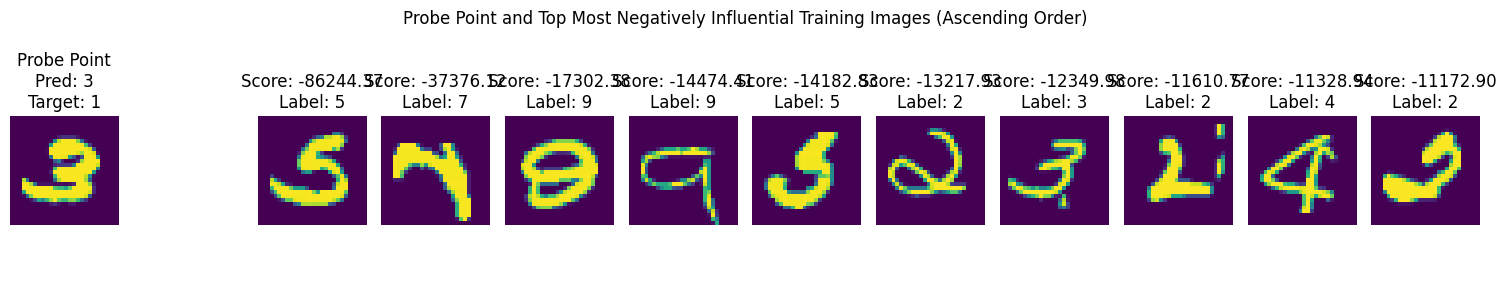


Influence Score Statistics:
  Min: -86244.3672
  Max: 106510.2656
  Mean: 7.8096
  Std: 972.4522

Top 5 Most Negatively Influential Training Examples:
  1. Index 30983: Label 5, Score -86244.3672
  2. Index 1171: Label 7, Score -37376.1211
  3. Index 21230: Label 9, Score -17302.3828
  4. Index 26991: Label 9, Score -14474.4131
  5. Index 19684: Label 5, Score -14182.8252


In [16]:
import numpy as np

def to_display_img(img):
    """
    Converts a tensor or numpy array image of shape (C, H, W) 
    to a valid image shape for matplotlib imshow.
    """
    if isinstance(img, np.ndarray):
        arr = img
    else:
        arr = img.numpy()
    if arr.ndim == 3 and arr.shape[0] in [1, 3]:
        # (C, H, W) -> (H, W, C)
        arr = np.transpose(arr, (1, 2, 0))
        if arr.shape[2] == 1:
            arr = arr[:, :, 0]  # For single channel images, drop the last dimension
    elif arr.ndim == 2:
        pass  # Already (H, W)
    return arr

# Visualize the probe point and its most influential training examples (most negative scores)
n_examp = 10
fig, axs = plt.subplots(ncols=2+n_examp, figsize=(15, 3))
fig.suptitle("Probe Point and Top Most Negatively Influential Training Images (Ascending Order)")

# Show probe point
axs[0].imshow(to_display_img(x_star))
axs[0].axis("off")
axs[0].set_title(f"Probe Point\nPred: {y_pred}\nTarget: {y_star}")
axs[1].axis("off")

# Show top most influential training examples (lowest scores = most negative influence)
top_k_indices = probe_scores.argsort(descending=False)[:args.top_k]
for ii, idx in enumerate(top_k_indices[:n_examp]):
    train_img, train_label = train_ds[idx]
    axs[ii + 2].imshow(to_display_img(train_img))
    axs[ii + 2].axis("off")
    axs[ii + 2].set_title(f"Score: {probe_scores[idx]:.2f}\nLabel: {train_label}")

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.4f}")
print(f"  Max: {probe_scores.max():.4f}")
print(f"  Mean: {probe_scores.mean():.4f}")
print(f"  Std: {probe_scores.std():.4f}")

print(f"\nTop 5 Most Negatively Influential Training Examples:")
for i, idx in enumerate(top_k_indices[:5]):
    train_img, train_label = train_ds[idx]
    print(f"  {i+1}. Index {idx}: Label {train_label}, Score {probe_scores[idx]:.4f}")

In [17]:
top_k_indices


tensor([30983,  1171, 21230, 26991, 19684,  4586, 49963, 42584, 11630, 50312,
        48507, 29999, 42765, 20274, 30265, 16316, 39446, 39428,  6188, 33240,
        18990, 20139,  5712,  6037, 12279, 46824, 25252, 46955, 39147, 44708,
         4235, 48623, 15706])

In [21]:
print("fc1 inverse_hessian_vector_product", model.fc1.storage["inverse_hessian_vector_product"].shape)
print("fc2 inverse_hessian_vector_product", model.fc2.storage["inverse_hessian_vector_product"].shape)
print("model", model)

fc1 inverse_hessian_vector_product torch.Size([1, 12, 785])
fc2 inverse_hessian_vector_product torch.Size([1, 10, 13])
model TwoLayerNet(
  (fc1): TrackedLinear(
    (original_module): Linear(in_features=784, out_features=12, bias=True)
  )
  (relu): ReLU()
  (fc2): TrackedLinear(
    (original_module): Linear(in_features=12, out_features=10, bias=True)
  )
)


## 7. Compute Optimal Perturbations via PGD

Apply projected gradient descent in input space:

$$z_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(z_t + \alpha \cdot \text{sign}(G_\delta(z_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$

In [ ]:
# """
# Perturbation computation and PGD optimization (fixed for allow_unused error)

# Mathematical background:
# - G_δ = -(1/n)[∇_z ∇_θ L(z, θ)]^T v, where v = (H + λI)^{-1} ∇_θ f
# - δ_opt = argmax_δ {∇_θ f^T Δθ} where Δθ ≈ G_δ^T δ
# - PGD: z_{t+1} = Proj_{||·|| ≤ ε}(z_t + α · sign(G_δ))
# """

# import torch
# import torch.nn.functional as F

# def batch_from_subset(subset):
#     """
#     Given a Subset, stack images and labels into batches.
#     Assumes each entry is (img, label).
#     """
#     imgs, labels = zip(*[subset[i] for i in range(len(subset))])
#     X = torch.stack(imgs, dim=0)
#     y = torch.tensor(labels, dtype=torch.long)
#     return X, y

# def flatten_params(param_list):
#     """Flatten list of tensors into a single vector"""
#     return torch.cat([p.reshape(-1) for p in param_list])

# def compute_G_delta_from_subset(model, subset, v, n_train):
#     """
#     Compute G_delta from a Subset, rather than from explicit X_batch, y_batch.
#     v should be a single flat vector (not a list).
#     Fix: Pass allow_unused=True to torch.autograd.grad in case
#          some params are not involved in loss.
#     """
#     X_batch, y_batch = batch_from_subset(subset)
#     params = [p for p in model.parameters() if p.requires_grad]
#     model.eval()

#     # Enable gradient w.r.t. inputs
#     X_batch = X_batch.detach().requires_grad_(True)

#     # Forward pass
#     logits = model(X_batch)
#     loss = F.cross_entropy(logits, y_batch, reduction='sum')  # sum for consistent scaling

#     # First backward: g = ∇_θ loss (as list of tensors); allow_unused True!
#     g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)

#     # Replace any None grads with zeros (for unused parameters)
#     g_list = [
#         torch.zeros_like(p) if g is None else g
#         for g, p in zip(g_list, params)
#     ]

#     # Flatten g_list to match v
#     g_flat = flatten_params(g_list)

#     # Dot product: s = g^T v (scalar)
#     s = torch.dot(g_flat, v)

#     # Second backward: ∇_x s = [∇_x ∇_θ L]^T v
#     Jt_v = torch.autograd.grad(s, X_batch, retain_graph=False, create_graph=False, allow_unused=True)[0]

#     # Scale and negate
#     G_delta = -(1.0 / n_train) * Jt_v

#     return G_delta

# def apply_pgd_perturbation(model, subset, v, n_train,
#                                        epsilon=2.0, alpha=0.3, n_steps=20, norm='inf',
#                                        verbose=False, return_stats=False):
#     """
#     Apply PGD to find optimal perturbations that maximize observable f(θ)
#     Works with a Subset, not with raw batches.

#     Args:
#         model: Trained model
#         subset: torch.utils.data.Subset of training data (imgs + labels)
#         v: IHVP vector (flattened)
#         n_train: Training set size
#         epsilon: L_∞ or L_2 perturbation budget
#         alpha: Step size
#         n_steps: Number of PGD iterations
#         norm: 'inf' or '2'
#         verbose: Print convergence diagnostics
#         return_stats: If True, return (X_perturbed, norms, stats_dict)

#     Returns:
#         X_perturbed: Perturbed batch [B, D]
#         perturbation_norms: Norms of final perturbations [B]
#         stats (optional): Dictionary with gradient and perturbation histories
#     """
#     X_batch, y_batch = batch_from_subset(subset)
#     X_orig = X_batch.clone()
#     X_adv = X_batch.clone()
#     B = X_batch.size(0)

#     def project_linf(x0, x_cand, eps):
#         return torch.clamp(x_cand, x0 - eps, x0 + eps)

#     def project_l2(x0, x_cand, eps):
#         delta = x_cand - x0
#         norms = torch.norm(delta.reshape(B, -1), p=2, dim=1, keepdim=True)
#         scale = torch.clamp(eps / (norms + 1e-12), max=1.0)
#         return x0 + delta * scale.reshape(-1, *([1] * (delta.ndim - 1)))

#     # Always track convergence for return_stats
#     grad_norms = []
#     pert_norms_history = []

#     # PGD iterations
#     for step in range(n_steps):
#         # Compute gradient direction
#         G_delta = compute_G_delta_from_subset(model, subset_from_tensors(X_adv, y_batch), v, n_train)

#         # Track metrics
#         gnorm = G_delta.abs().mean().item()
#         grad_norms.append(gnorm)

#         current_delta = X_adv - X_orig
#         if norm == 'inf':
#             pnorm = torch.norm(current_delta.reshape(B, -1), p=float('inf'), dim=1).mean().item()
#         else:
#             pnorm = torch.norm(current_delta.reshape(B, -1), p=2, dim=1).mean().item()
#         pert_norms_history.append(pnorm)

#         if verbose and (step % 10 == 0 or step == n_steps - 1):
#             print(f"  Step {step:3d}: ||G_δ|| = {gnorm:.6f}, ||δ|| = {pnorm:.6f}")

#         # Take step
#         if norm == 'inf':
#             step_vec = alpha * torch.sign(G_delta)
#             X_cand = X_adv + step_vec
#             X_adv = project_linf(X_orig, X_cand, epsilon)
#         elif norm == '2':
#             g_norms = torch.norm(G_delta.reshape(B, -1), p=2, dim=1, keepdim=True) + 1e-12
#             step_vec = alpha * (G_delta / g_norms.reshape(-1, 1))
#             X_cand = X_adv + step_vec
#             X_adv = project_l2(X_orig, X_cand, epsilon)
#         else:
#             raise ValueError(f"Unknown norm: {norm}")

#     # Compute final perturbation norms
#     delta = X_adv - X_orig
#     if norm == 'inf':
#         pert_norms = torch.norm(delta.reshape(B, -1), p=float('inf'), dim=1)
#     else:
#         pert_norms = torch.norm(delta.reshape(B, -1), p=2, dim=1)

#     # Print convergence analysis
#     if verbose:
#         print(f"\nConvergence Analysis:")
#         print(f"  Initial gradient norm: {grad_norms[0]:.6f}")
#         print(f"  Final gradient norm: {grad_norms[-1]:.6f}")
#         print(f"  Gradient reduction: {grad_norms[-1]/grad_norms[0]:.2e}")
#         print(f"  Final perturbation norm: {pert_norms_history[-1]:.6f}")
#         print(f"  Epsilon budget: {epsilon:.6f}")
#         if pert_norms_history[-1] < epsilon * 0.9:
#             print(f"  → PGD CONVERGED before hitting epsilon constraint")
#         else:
#             print(f"  → Hit epsilon constraint")

#     if return_stats:
#         stats = {
#             'initial_grad_norm': grad_norms[0],
#             'final_grad_norm': grad_norms[-1],
#             'gradient_reduction': grad_norms[-1] / (grad_norms[0] + 1e-12),
#             'grad_history': grad_norms,
#             'pert_norms_history': pert_norms_history,
#             'converged': pert_norms_history[-1] < epsilon * 0.9
#         }
#         return X_adv, pert_norms, stats

#     return X_adv, pert_norms

# def subset_from_tensors(X, y):
#     """
#     Utility to wrap (X, y) tensors into a Subset-like object
#     so that later PGD steps keep compatible usage.
#     """
#     class TensorSubset:
#         def __init__(self, X_tensor, y_tensor):
#             self.X = X_tensor
#             self.y = y_tensor
#             self.n = X_tensor.size(0)
#         def __len__(self):
#             return self.n
#         def __getitem__(self, idx):
#             # Mimic Dataset behavior
#             return self.X[idx], self.y[idx]
#     return TensorSubset(X, y)

In [22]:

import torch
import torch.nn.functional as F

# --------------------------
# Dataset helpers
# --------------------------

def batch_from_subset(subset):
    imgs, labels = zip(*[subset[i] for i in range(len(subset))])
    X = torch.stack(imgs, dim=0)
    y = torch.tensor(labels, dtype=torch.long)
    return X, y

def subset_from_tensors(X, y):
    class TensorSubset:
        def __init__(self, X_tensor, y_tensor):
            self.X = X_tensor
            self.y = y_tensor
            self.n = X_tensor.size(0)
        def __len__(self): return self.n
        def __getitem__(self, idx): return self.X[idx], self.y[idx]
    return TensorSubset(X, y)

# --------------------------
# Utilities for storage/IHVP access
# --------------------------

def _unwrap_original_module(mod):
    """
    Recursively unwrap .original_module if present.
    Returns the deepest module and the chain (for optional debugging).
    """
    chain = [mod]
    cur = mod
    while hasattr(cur, "original_module") and cur.original_module is not None:
        cur = cur.original_module
        chain.append(cur)
    return cur, chain

def _get_storage(mod):
    """
    Try to find a .storage dict on mod or on any .original_module in the chain.
    Returns the storage dict or None.
    """
    # Try on the module itself
    if hasattr(mod, "storage") and isinstance(mod.storage, dict):
        return mod.storage
    # Try unwrap chain
    cur = mod
    while hasattr(cur, "original_module") and cur.original_module is not None:
        cur = cur.original_module
        if hasattr(cur, "storage") and isinstance(cur.storage, dict):
            return cur.storage
    return None

def _ihvp_layer_to_weight_bias(v_layer_1OI1, has_bias, weight_shape):
    """
    Convert per-layer IHVP [1, O, I + (1 if has_bias else 0)] to flattened vectors
    matching torch.flatten(order='C') semantics on the actual param tensors.

    Args:
      v_layer_1OI1: Tensor of shape [1, O, I{+}1_bias]
      has_bias: bool
      weight_shape: the actual param shape of the module's weight tensor (e.g., (O,I) or (O, Cin, kH, kW))

    Returns:
      vW_flat: flattened to match weight.flatten()
      vB_flat: flattened to match bias.flatten() (or None if no bias)
    """
    v = v_layer_1OI1.squeeze(0).detach()  # [O, I1]
    O = weight_shape[0]
    I_flat = int(torch.tensor(weight_shape[1:]).prod().item()) if len(weight_shape) > 1 else 1
    I1 = v.shape[1]
    if has_bias:
        assert I1 == I_flat + 1, f"IHVP shape mismatch: expected I+1={I_flat+1}, got {I1}"
        vW = v[:, :I_flat]     # [O, I_flat]
        vB = v[:,  I_flat]     # [O]
        vB_flat = vB.reshape(-1).contiguous()
    else:
        assert I1 == I_flat, f"IHVP shape mismatch: expected I={I_flat}, got {I1}"
        vW = v                   # [O, I_flat]
        vB_flat = None
    # To match torch.flatten(weight) we reshape [O, I_flat] back to weight_shape then flatten
    vW_flat = vW.reshape((O, I_flat)).reshape(*weight_shape).contiguous().reshape(-1)
    return vW_flat, vB_flat

# --------------------------
# Model-agnostic v builder
# --------------------------

def build_v_flat_all(model, fill_missing_with_zeros=True, verbose=True):
    """
    Build a whole-model flattened IHVP vector matching *exactly* the order of list(model.parameters()).

    - Looks for per-layer IHVPs at storage["inverse_hessian_vector_product"] located either on the module
      itself or on any nested .original_module.
    - Supports Linear/Conv-like modules where the IHVP is stored as [1, O, I + 1_{bias}], with the *last column* as bias.
    - For parameters without an IHVP available (e.g., BN, embeddings, or layers not wrapped), fills zeros if
      fill_missing_with_zeros=True; otherwise raises.

    Returns:
      v_flat_all (1-D tensor)
    """
    # Precompute a mapping from each leaf parameter tensor to the module that owns it (non-recursive at that level)
    # We'll iterate all named_modules; for each module, gather its own (recurse=False) params.
    param_to_owner = {}
    for mod in model.modules():
        for name, p in mod.named_parameters(recurse=False):
            if p is not None:
                param_to_owner[p] = mod

    # For each owner module, try to fetch IHVP from storage.
    owner_to_vecs = {}  # module -> dict {'weight': vW_flat, 'bias': vB_flat or None}
    for owner in set(param_to_owner.values()):
        # Only consider modules that actually have a 'weight' param at this non-recursive level
        local_params = dict(owner.named_parameters(recurse=False))
        if "weight" not in local_params:
            continue
        weight = local_params["weight"]
        bias = local_params.get("bias", None)
        has_bias = bias is not None

        storage = _get_storage(owner)
        if storage is None or "inverse_hessian_vector_product" not in storage:
            # No IHVP; we'll decide later how to handle missing
            continue

        ihvp = storage["inverse_hessian_vector_product"]
        try:
            vW_flat, vB_flat = _ihvp_layer_to_weight_bias(ihvp, has_bias=has_bias, weight_shape=tuple(weight.shape))
        except AssertionError as e:
            raise RuntimeError(f"IHVP/param shape mismatch for module {owner}: {e}")

        owner_to_vecs[owner] = {"weight": vW_flat, "bias": vB_flat}

    # Now assemble v in the exact order of model.parameters()
    parts = []
    missing = []
    for p in model.parameters():
        owner = param_to_owner.get(p, None)
        if owner is None:
            # Param not found in our owner map (rare). Zero-fill or raise.
            if fill_missing_with_zeros:
                parts.append(torch.zeros(p.numel(), dtype=p.dtype, device=p.device))
                missing.append(("unknown_owner", tuple(p.shape)))
                continue
            else:
                raise RuntimeError(f"Could not identify owner module for param with shape {tuple(p.shape)}.")
        # Decide which slice to take
        is_weight = False
        for nm, lp in owner.named_parameters(recurse=False):
            if lp is p and nm == "weight":
                is_weight = True
                break
        if owner in owner_to_vecs:
            vecs = owner_to_vecs[owner]
            if is_weight:
                parts.append(vecs["weight"].to(p.device, p.dtype))
            else:
                # bias or other param at this level
                if "bias" in vecs and vecs["bias"] is not None and p is getattr(owner, "bias", None):
                    parts.append(vecs["bias"].to(p.device, p.dtype))
                else:
                    # Owner had IHVP but not for this param (e.g., no bias in layer)
                    if fill_missing_with_zeros:
                        parts.append(torch.zeros(p.numel(), dtype=p.dtype, device=p.device))
                        missing.append((owner.__class__.__name__ + "_extra", tuple(p.shape)))
                    else:
                        raise RuntimeError(f"No IHVP slice for param {p.shape} in owner {owner}.")
        else:
            # This owner had no IHVP in storage
            if fill_missing_with_zeros:
                parts.append(torch.zeros(p.numel(), dtype=p.dtype, device=p.device))
                missing.append((owner.__class__.__name__, tuple(p.shape)))
            else:
                raise RuntimeError(f"Missing IHVP for owner {owner} (param shape {tuple(p.shape)}).")

    v_flat_all = torch.cat(parts, dim=0)

    if verbose:
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"[IHVP] Built whole-model v: {v_flat_all.numel()} elements "
              f"(trainable params: {num_params}). Missing slices filled: {len(missing)}")
        if len(missing) > 0:
            # Print a short summary of what was zero-filled (once per unique (owner,shape))
            from collections import Counter
            c = Counter(missing)
            top = ", ".join([f"{k}×{v}" for k, v in c.items()])
            print(f"[IHVP] Zero-filled: {top}")

    return v_flat_all

# --------------------------
# Core G_delta computation (whole model)
# --------------------------

def compute_G_delta_whole_model(model, subset, v_flat_all, n_train):
    """
    G_delta = -(1/n) [∇_z ∇_θ L]^T v, using *all* params in the current model.
    """
    X_batch, y_batch = batch_from_subset(subset)
    X_batch = X_batch.detach().requires_grad_(True)
    model.eval()

    params = [p for p in model.parameters() if p.requires_grad]

    logits = model(X_batch)
    loss = F.cross_entropy(logits, y_batch, reduction='sum')

    g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
    g_list = [torch.zeros_like(p) if g is None else g for g, p in zip(g_list, params)]
    g_flat = torch.cat([g.reshape(-1) for g in g_list], dim=0)

    v_flat_all = v_flat_all.to(g_flat.device, g_flat.dtype).detach()
    s = torch.dot(g_flat, v_flat_all)
    Jt_v = torch.autograd.grad(s, X_batch, retain_graph=False, create_graph=False)[0]

    return -(1.0 / n_train) * Jt_v

# --------------------------
# PGD (L_inf or L2)
# --------------------------

def apply_pgd_perturbation(
    model,
    subset,
    v_flat_all,
    n_train,
    epsilon=2.0,
    alpha=0.3,
    n_steps=20,
    norm='inf',
    clamp_range=(0.0, 1.0),
    verbose=False,
    return_stats=False
):
    X_batch, y_batch = batch_from_subset(subset)
    X_orig = X_batch.clone()
    X_adv = X_batch.clone()
    B = X_batch.size(0)

    def project_linf(x0, x_cand, eps):
        return torch.clamp(x_cand, x0 - eps, x0 + eps)

    def project_l2(x0, x_cand, eps):
        delta = x_cand - x0
        norms = torch.norm(delta.reshape(B, -1), p=2, dim=1, keepdim=True)
        scale = torch.clamp(eps / (norms + 1e-12), max=1.0)
        return x0 + delta * scale.reshape(-1, *([1] * (delta.ndim - 1)))

    grad_norms, pert_norms_history = [], []

    for step in range(n_steps):
        G_delta = compute_G_delta_whole_model(
            model,
            subset_from_tensors(X_adv, y_batch),
            v_flat_all,
            n_train
        )

        gnorm = G_delta.abs().mean().item()
        grad_norms.append(gnorm)

        current_delta = X_adv - X_orig
        if norm == 'inf':
            pnorm = torch.norm(current_delta.reshape(B, -1), p=float('inf'), dim=1).mean().item()
        else:
            pnorm = torch.norm(current_delta.reshape(B, -1), p=2, dim=1).mean().item()
        pert_norms_history.append(pnorm)

        if verbose and (step % 10 == 0 or step == n_steps - 1):
            print(f"  Step {step:3d}: ||G_δ|| = {gnorm:.6f}, ||δ|| = {pnorm:.6f}")

        if norm == 'inf':
            step_vec = alpha * torch.sign(G_delta)
            X_cand = X_adv + step_vec
            X_adv = project_linf(X_orig, X_cand, epsilon)
        elif norm == '2':
            g_norms = torch.norm(G_delta.reshape(B, -1), p=2, dim=1, keepdim=True) + 1e-12
            step_vec = alpha * (G_delta / g_norms.reshape(-1, *([1] * (G_delta.ndim - 1))))
            X_cand = X_adv + step_vec
            X_adv = project_l2(X_orig, X_cand, epsilon)
        else:
            raise ValueError(f"Unknown norm: {norm}")

        if clamp_range is not None:
            lo, hi = clamp_range
            X_adv = torch.clamp(X_adv, lo, hi)

    delta = X_adv - X_orig
    if norm == 'inf':
        pert_norms = torch.norm(delta.reshape(B, -1), p=float('inf'), dim=1)
    else:
        pert_norms = torch.norm(delta.reshape(B, -1), p=2, dim=1)

    if verbose:
        print(f"\nConvergence Analysis:")
        print(f"  Initial gradient norm: {grad_norms[0]:.6f}")
        print(f"  Final gradient norm: {grad_norms[-1]:.6f}")
        print(f"  Gradient reduction: {grad_norms[-1]/(grad_norms[0] + 1e-12):.2e}")
        print(f"  Final perturbation norm: {pert_norms_history[-1]:.6f}")
        print(f"  Epsilon budget: {epsilon:.6f}")
        if pert_norms_history[-1] < epsilon * 0.9:
            print(f"  → PGD CONVERGED before hitting epsilon constraint")
        else:
            print(f"  → Hit epsilon constraint")

    if return_stats:
        stats = {
            'initial_grad_norm': grad_norms[0],
            'final_grad_norm': grad_norms[-1],
            'gradient_reduction': grad_norms[-1] / (grad_norms[0] + 1e-12),
            'grad_history': grad_norms,
            'pert_norms_history': pert_norms_history,
            'converged': pert_norms_history[-1] < epsilon * 0.9
        }
        return X_adv, pert_norms, stats

    return X_adv, pert_norms

In [ ]:
print(f"Applying PGD perturbation...")
print(f"  ε = {args.epsilon} (L_∞ budget)")
print(f"  α = {args.alpha} (step size)")
print(f"  Steps = {args.n_steps}\n")

N = len(train_ds)
from torch.utils.data import Subset
top_k_ds = Subset(train_ds, [int(idx) for idx in top_k_indices])

v = model.linear.storage["inverse_hessian_vector_product"]
# torch.Size([1, 10, 785])



# Apply PGD with convergence monitoring
X_perturbed, pert_norms = apply_pgd_perturbation(
    model, top_k_ds, v, N,
    epsilon=args.epsilon,
    alpha=args.alpha,
    n_steps=args.n_steps,
    norm='inf',
    verbose=True  # Show convergence diagnostics
)

print(f"\nPerturbation applied!")
print(f"  Mean L_∞ norm: {pert_norms.mean():.4f}")
print(f"  Max L_∞ norm: {pert_norms.max():.4f}")

Applying PGD perturbation...
  ε = 1 (L_∞ budget)
  α = 0.02 (step size)
  Steps = 10



NameError: name 'top_k_indices' is not defined

In [ ]:
# Visualize perturbations
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(16, 6))

for i in range(n_show):
    # Original
    axes[0, i].imshow(X_selected[i].cpu().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10)
    
    # Perturbed
    axes[1, i].imshow(X_perturbed[i].cpu().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Perturbed', fontsize=10)
    
    # Difference (amplified for visibility)
    diff = (X_perturbed[i] - X_selected[i]).cpu().reshape(28, 28)
    axes[2, i].imshow(diff, cmap='bwr', vmin=-args.epsilon, vmax=args.epsilon)
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Δ (difference)', fontsize=10)

plt.suptitle(f'Perturbations (ε={args.epsilon})', fontsize=12)
plt.tight_layout()
plt.show()